# Polarization of Light --> Malus Law

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Exercise 1: Two Polarizers
Export data, analyze dependencies: Intensity vs. cos θ, and Intensity vs. cos<sup>2</sup>θ

### Organize data

In [86]:
# import data
ex1_01 = pd.read_csv("./Exercise1/Ex1_01.txt", sep='\t', header=1, skiprows=0)
ex1_02 = pd.read_csv("./Exercise1/Ex1_02.txt", sep='\t', header=1, skiprows=0)
ex1_03 = pd.read_csv("./Exercise1/Ex1_03.txt", sep='\t', header=1, skiprows=0)

display(ex1_01.head())
display(ex1_02.tail())

ex1 = [ex1_01, ex1_02, ex1_03]
display(ex1[2].tail())

,Sensor Position (Radians),Light Intensity (Volts)
0,0.0,4.46213
1,0.0,4.46068
2,0.0,4.46262
3,0.0,4.46020
4,0.0,4.45778


,Sensor Position (Radians),Light Intensity (Volts)
269,3.12850,4.37611
270,3.12850,4.36870
271,3.12850,4.37837
272,3.13287,4.35968
273,3.15032,4.34647


,Sensor Position (Radians),Light Intensity (Volts)
219,3.05869,4.27914
220,3.08487,4.24144
221,3.10669,4.20923
222,3.12850,4.18007
223,3.14596,4.15381


In [87]:
# order by intensity 
for i in range(0, len(ex1)):
    ex1[i] = ex1[i].sort_values(by=["Light Intensity (Volts)"], ascending=True)
    ex1[i] = ex1[i].reset_index(drop=True)
display(ex1[2])

,Sensor Position (Radians),Light Intensity (Volts)
0,1.33954,-0.01245
1,1.32645,-0.01229
2,1.35699,-0.01213
3,1.30900,-0.00762
4,1.37881,-0.00746
...,...,...
219,2.86234,4.37917
220,2.84052,4.40640
221,2.85798,4.41187
222,2.85361,4.41848


### Plot Intensity vs cos(θ)

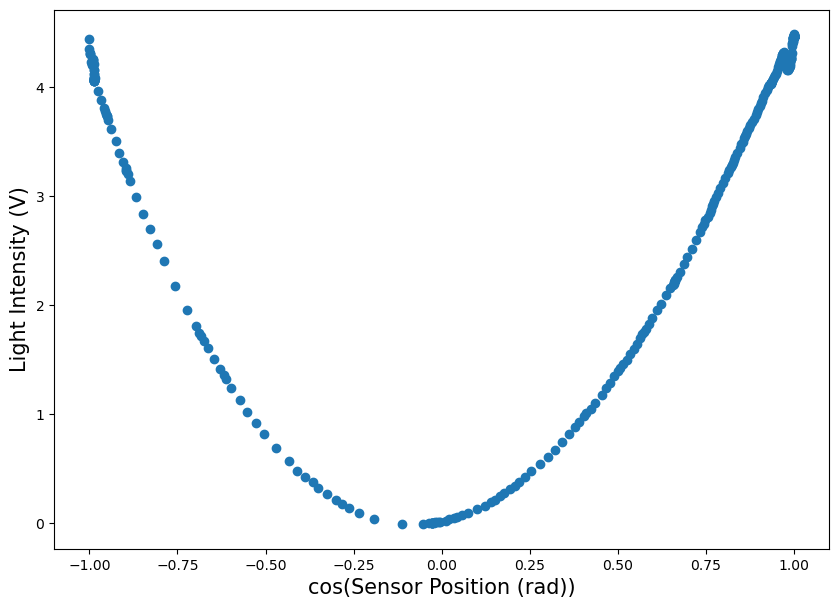

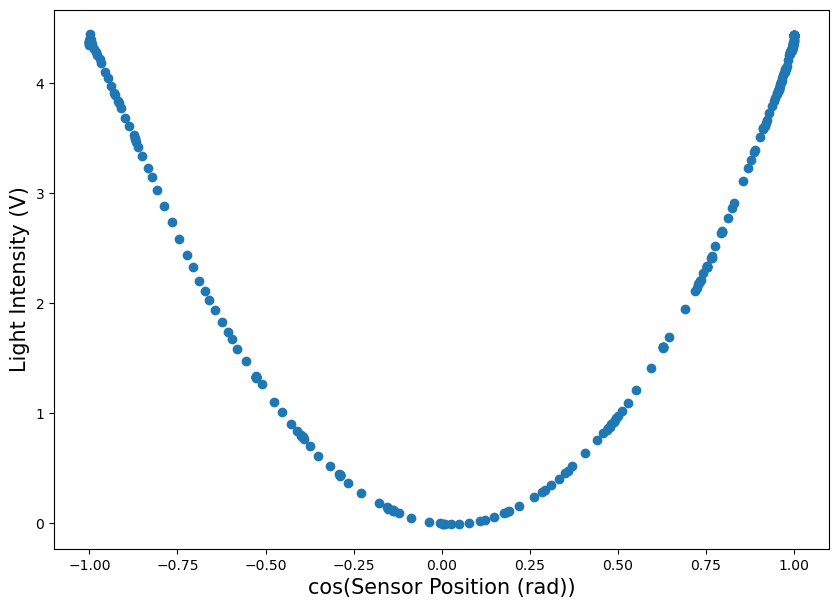

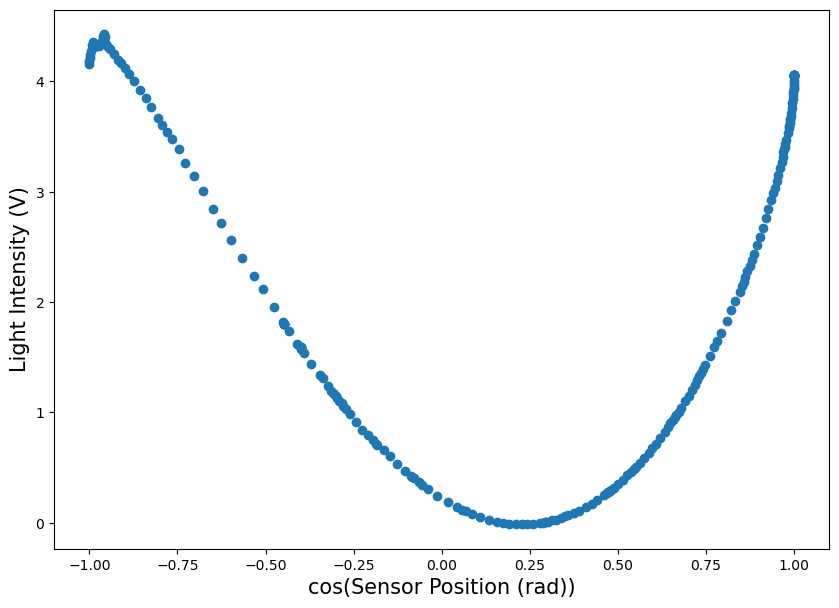

In [92]:
for i in range(0, len(ex1)):
    # make the data
    x = np.array(np.cos(ex1[i]['Sensor Position (Radians)'].to_list())) # cos(θ)
    y = np.array(ex1[i]['Light Intensity (Volts)'].to_list()) # intensity
    # MAKE ERRORBARS
    
    # plot
    fig, ax = plt.subplots()
    ax.scatter(x, y)
    ax.set_ylabel("Light Intensity (V)", fontsize=15)
    ax.set_xlabel("cos(Sensor Position (rad))", fontsize=15)
    #ax.errorbar(x, y, xerr=x_err, yerr=y_err[i], fmt='none')
    fig.set_size_inches(10, 7)

    # save
    name = "intensityvscos_" + str(i) + ".png"
    fig.savefig(name, bbox_inches='tight', pad_inches=0.5)

### Plot Intensity vs cos(θ)

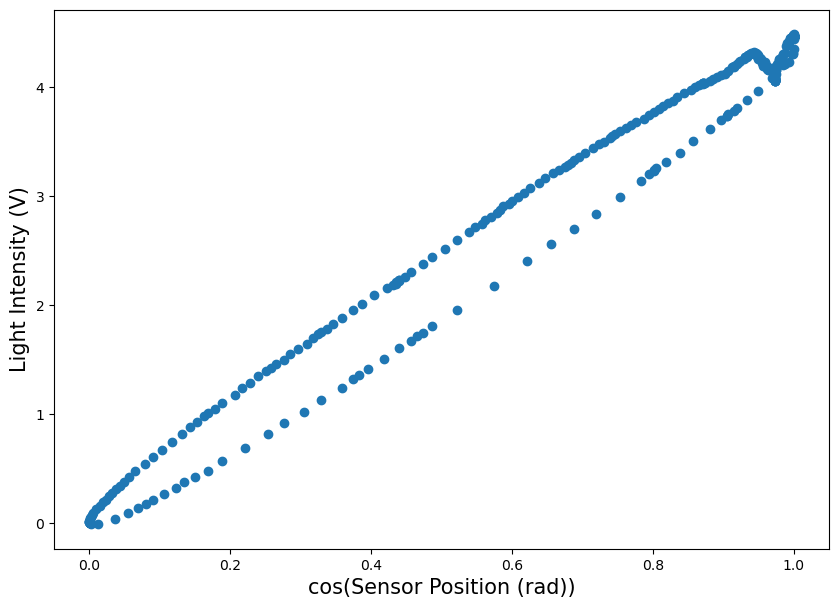

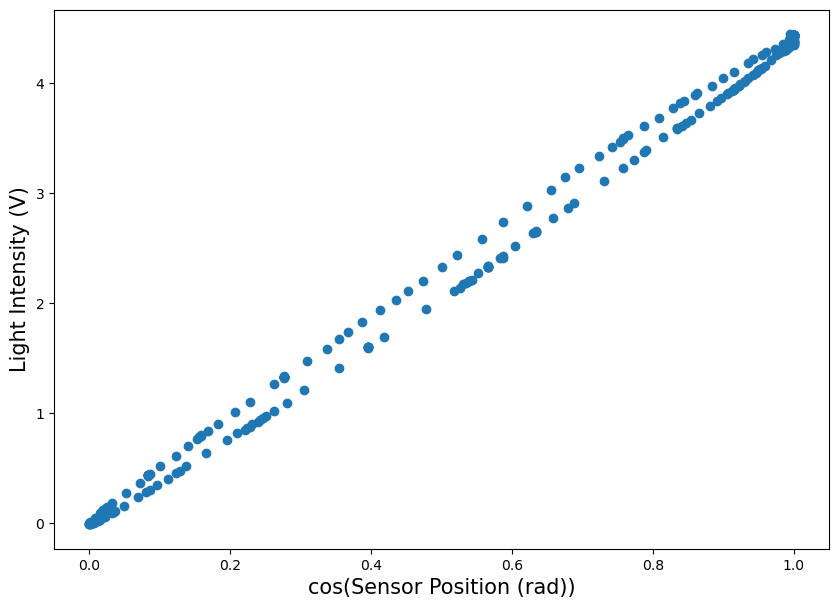

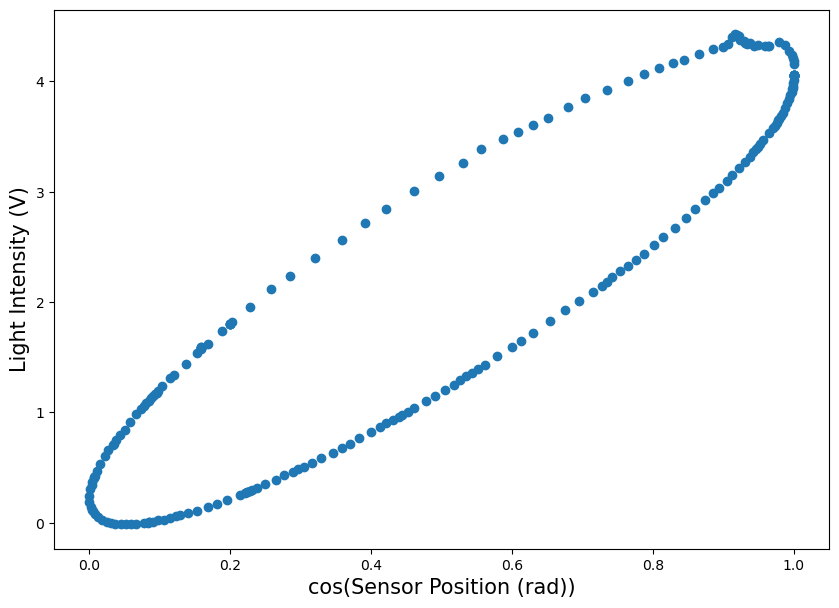

In [93]:
for i in range(0, len(ex1)):
    # make the data
    x = np.array((np.cos(ex1[i]['Sensor Position (Radians)'].to_list()))**2) # cos(θ)
    y = np.array(ex1[i]['Light Intensity (Volts)'].to_list()) # intensity
    # MAKE ERRORBARS
    
    # plot
    fig, ax = plt.subplots()
    ax.scatter(x, y)
    ax.set_ylabel("Light Intensity (V)", fontsize=15)
    ax.set_xlabel("cos(Sensor Position (rad))", fontsize=15)
    #ax.errorbar(x, y, xerr=x_err, yerr=y_err[i], fmt='none')
    fig.set_size_inches(10, 7)

    # save
    name = "intensityvscos2_" + str(i) + ".png"
    fig.savefig(name, bbox_inches='tight', pad_inches=0.5)

### Ex1 Failed Attempts

#### Idea to combine them into 1 df

In [77]:
# combine them
ex1_all = pd.concat(ex1, ignore_index=True)
ex1_all.info()
display(ex1_all.tail())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 818 entries, 0 to 817
Data columns (total 2 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Sensor Position (Radians)  818 non-null    float64
 1   Light Intensity (Volts)    818 non-null    float64
dtypes: float64(2)
memory usage: 12.9 KB


,Sensor Position (Radians),Light Intensity (Volts)
813,3.05869,4.27914
814,3.08487,4.24144
815,3.10669,4.20923
816,3.12850,4.18007
817,3.14596,4.15381


In [78]:
# order by intensity
ex1_all = ex1_all.sort_values(by=["Light Intensity (Volts)"], ascending=True)
ex1_all = ex1_all.reset_index(drop=True)
display(ex1_all)
#display(ex1_all.iloc[10:30])
#display(ex1_all.tail())

,Sensor Position (Radians),Light Intensity (Volts)
0,1.54462,-0.01342
1,1.56207,-0.01294
2,1.33954,-0.01245
3,1.32645,-0.01229
4,1.52280,-0.01229
...,...,...
813,0.04363,4.46987
814,0.01309,4.47663
815,0.02182,4.47905
816,0.03491,4.47921


In [79]:
# combine and get mean
ex1_all_comb = ex1_all.groupby('Light Intensity (Volts)').mean().reset_index()
ex1_all_comb.info()

# get std separately
temp_db = ex1_all.groupby('Light Intensity (Volts)').std().reset_index()
temp_db = temp_db.rename(columns={"Sensor Position (Radians)": "SP std"})

# combine
ex1_all_comb = pd.concat([ex1_all_comb, temp_db["SP std"]], axis=1)
display(ex1_all_comb)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 2 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Light Intensity (Volts)    780 non-null    float64
 1   Sensor Position (Radians)  780 non-null    float64
dtypes: float64(2)
memory usage: 12.3 KB


,Light Intensity (Volts),Sensor Position (Radians),SP std
0,-0.01342,1.544620,NaN
1,-0.01294,1.562070,NaN
2,-0.01245,1.339540,NaN
3,-0.01229,1.424625,0.13884
4,-0.01213,1.356990,NaN
...,...,...,...
775,4.46987,0.043630,NaN
776,4.47663,0.013090,NaN
777,4.47905,0.021820,NaN
778,4.47921,0.034910,NaN


### Exercise 1 Testing

In [66]:
# test combining 

test_db = ex1_all.iloc[10:30]
#display(test_db)

# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.groupby.html
# do std first bc will override df with mean
# - prob smarter to just make a separate one for the actual thing though
test1_db = test_db.groupby('Light Intensity (Volts)').std().reset_index()
test1_db = test1_db.rename(columns={"Sensor Position (Radians)": "SP std"})
#display(test1_db)

test_db = test_db.groupby('Light Intensity (Volts)').mean().reset_index()
#display(test_db)

test_db = pd.concat([test_db, test1_db["SP std"]], axis=1)

display(test_db)

,Light Intensity (Volts),Sensor Position (Radians),SP std
0,-0.00762,1.309000,NaN
1,-0.00746,1.378810,NaN
2,-0.00440,1.575160,NaN
3,-0.00327,1.605700,NaN
4,-0.00198,1.287180,NaN
5,-0.00166,1.596980,NaN
6,-0.00150,1.596980,NaN
7,-0.00118,1.596980,NaN
8,0.00059,1.437715,0.225235
9,0.00092,1.596980,NaN


## Exercise 2: Three Polarizers

### Organize Data

In [132]:
ex2 = []

# import data
for i in range(4, 7):    
    
    # get both halves for each trial
    df1 = pd.read_csv("./Exercise2/Ex2_0" + str(i) + ".1.txt", sep='\t', header=1, skiprows=0)
    df2 = pd.read_csv("./Exercise2/Ex2_0" + str(i) + ".2.txt", sep='\t', header=1, skiprows=0)
    #df1.info()
    #df2.info()

    # combine, reset indices
    df0 = pd.concat([df1, df2], ignore_index=True)
    #df0.info()

    # potentially sort by angle

    # add to list
    ex2.append(df0)
    #print()

# MAY NEED TO CLEAN UP BEGINNING DATA FOR EACH HALF 
#WHERE SENS POS DOESN'T CHANGE?
    
# add π rad (180º) to the second half of angles
ex2[0]['Sensor Position (Radians)'][172:] += ex2[0]['Sensor Position (Radians)'][171]
ex2[1]['Sensor Position (Radians)'][193:] += ex2[1]['Sensor Position (Radians)'][192]
ex2[2]['Sensor Position (Radians)'][174:] += ex2[2]['Sensor Position (Radians)'][173]

#display(ex2[0][167:177])
display(ex2[1][190:200])
#display(ex2[2][170:180])

,Sensor Position (Radians),Light Intensity (Volts)
190,3.01506,0.64556
191,3.08051,0.45839
192,3.22013,0.20227
193,3.22013,-0.00537
194,3.22013,-0.00521
195,3.22013,-0.00698
196,3.22013,-0.00585
197,3.22013,-0.00215
198,3.22013,-0.00601
199,3.22013,-0.00553


### Plot Intensity vs cos(θ)

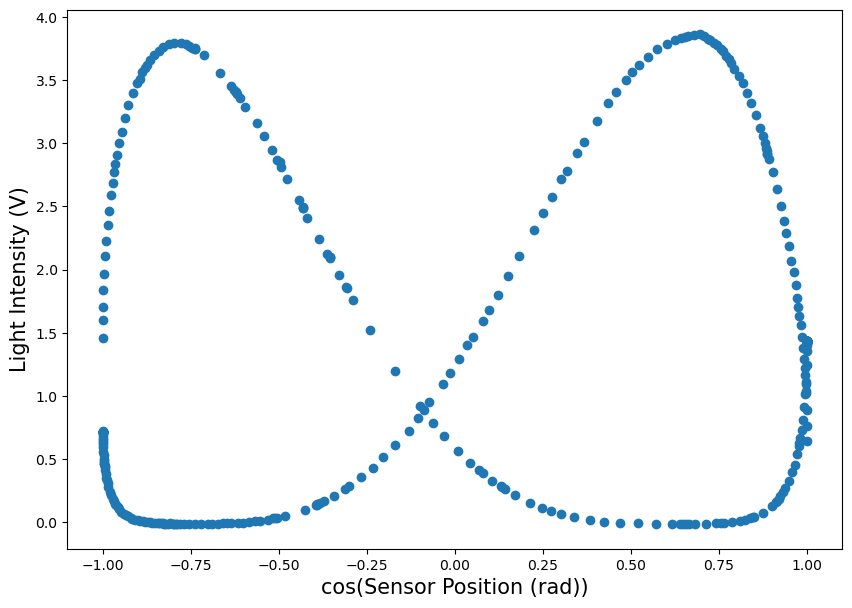

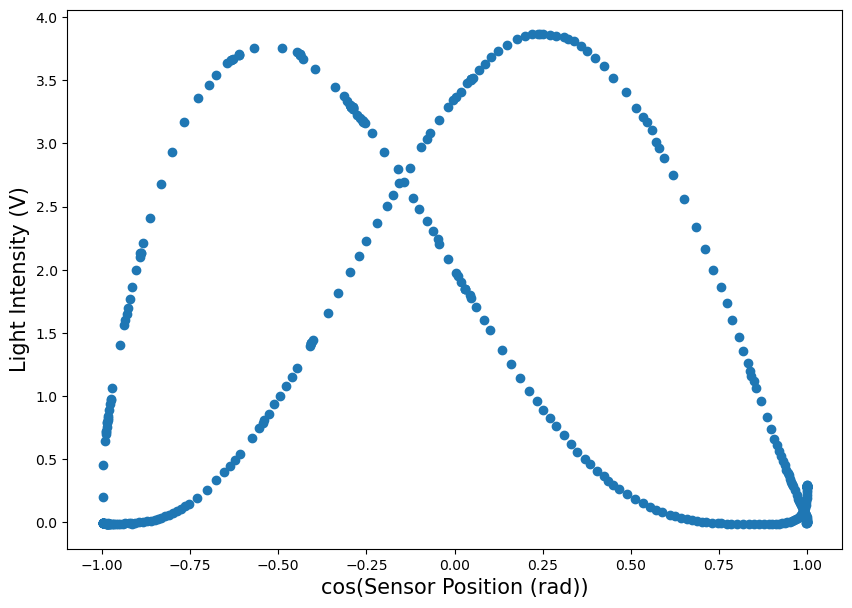

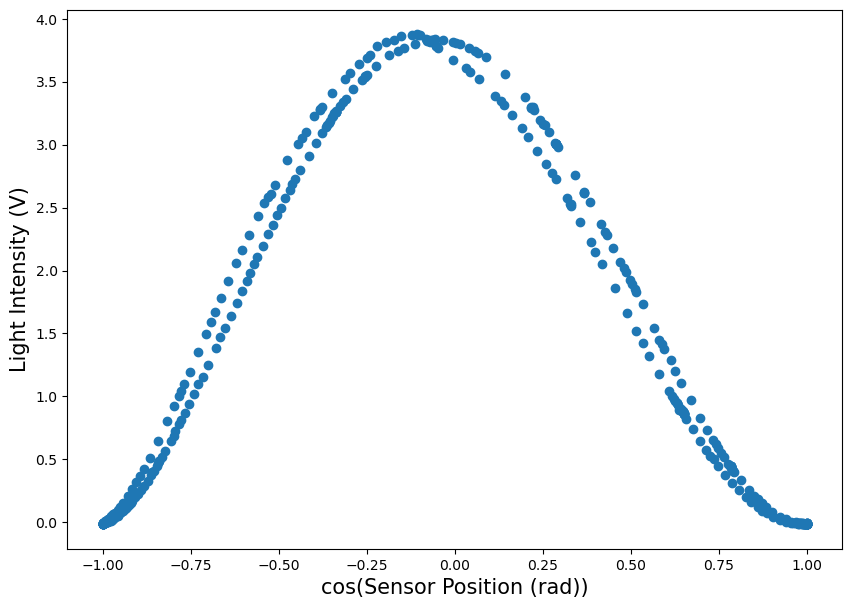

In [157]:
# Intensity vs cos(θ)
for i in range(0, len(ex2)):
    # make the data
    x = np.array(np.cos(ex2[i]['Sensor Position (Radians)'].to_list())) # cos(θ)
    y = np.array(ex2[i]['Light Intensity (Volts)'].to_list()) # intensity
    # MAKE ERRORBARS
    
    # plot
    fig, ax = plt.subplots()
    ax.scatter(x, y)
    ax.set_ylabel("Light Intensity (V)", fontsize=15)
    ax.set_xlabel("cos(Sensor Position (rad))", fontsize=15)
    #ax.errorbar(x, y, xerr=x_err, yerr=y_err[i], fmt='none')
    fig.set_size_inches(10, 7)

    # save
    name = "3p_intensityvscos_" + str(i) + ".png"
    fig.savefig(name, bbox_inches='tight', pad_inches=0.5)

### Plot Intensity vs θ?

In [158]:
# figure out the lines of best fit
# I will just take the average of the best fit (provided by the 
#software) for both halves
# y = a*cos(bx+c)+d

params = []
# 4
params.append([(1.92160 + 1.89824)/2,
               (1.89208 + 1.95506)/2,
               (1.54285 + 1.84948)/2, 
               (1.44313 + 1.45429)/2])
# 5
params.append([(-517.34590*10**(-3) + 1.94146)/2,
               (-12.45300 - 2.25993)/2,
               (-5.81020 + 3.94499)/2, 
               (1.38296 + 1.64698)/2])
# 6
params.append([(1.96415 + 1.91401)/2,
               (2.31062 + 2.43551)/2,
               (8.66311 - 3.66778)/2, 
               (1.64724 + 1.75314)/2])

print(params)

[[1.90992, 1.92357, 1.6961650000000001, 1.4487100000000002], [0.71205705, -7.356465, -0.9326049999999999, 1.51497], [1.9390800000000001, 2.373065, 2.4976649999999996, 1.70019]]


In [159]:
from scipy.optimize import curve_fit

# prep for lines of best fit with scipy curve_fit
# I(θ) = I0*[cos(θ)]^2
def malus(x, a):
    return a * (np.cos(x))**2

# y = a*cos(bx+c)+d
def fit(x, a, b, c, d):
    return a * np.cos(b*x + c) + d

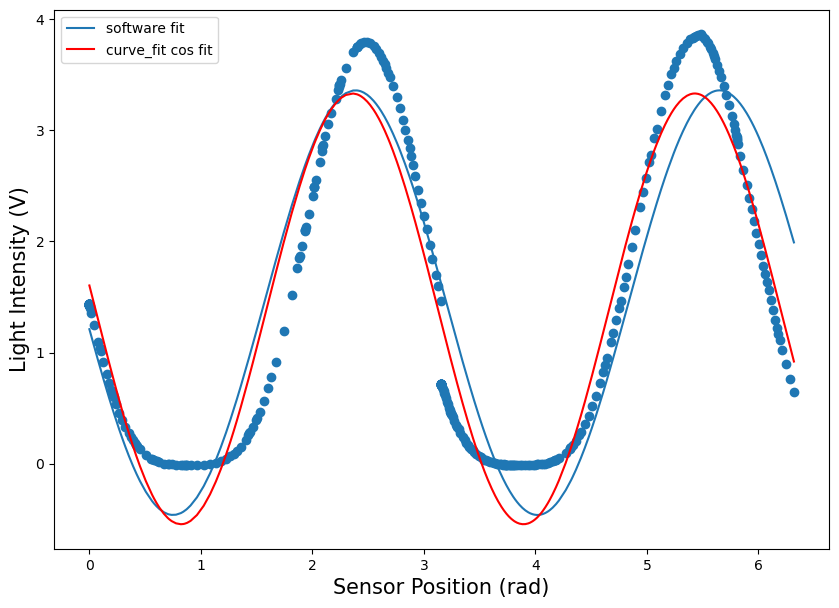

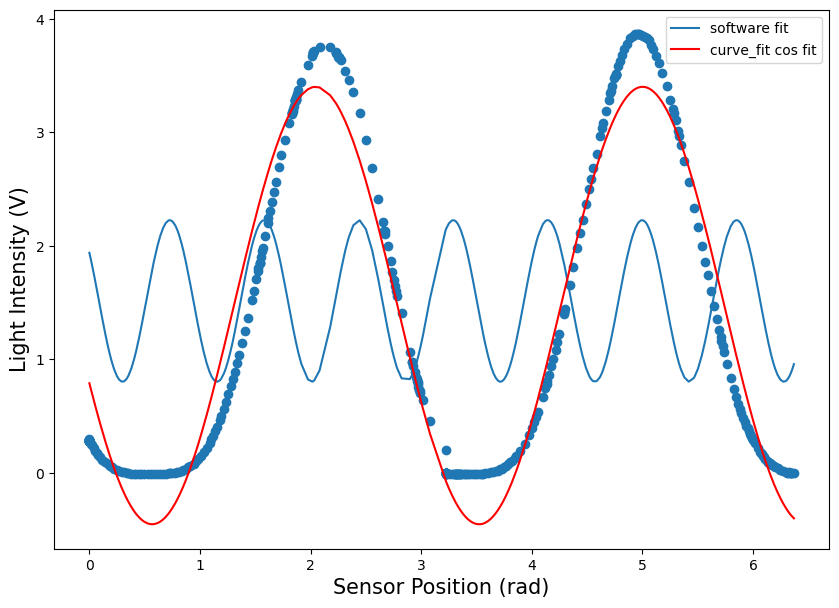

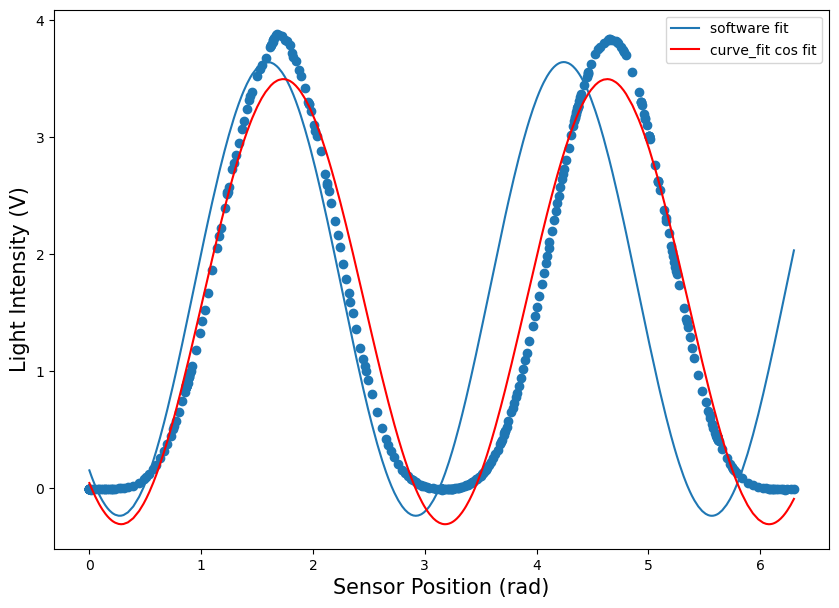

In [166]:
# Intensity vs θ
for i in range(0, len(ex2)):
    # make the data
    x = np.array(ex2[i]['Sensor Position (Radians)'].to_list()) # θ
    y = np.array(ex2[i]['Light Intensity (Volts)'].to_list()) # intensity
    # MAKE ERRORBARS
    
    # plot data
    fig, ax = plt.subplots()
    ax.scatter(x, y)
    ax.set_ylabel("Light Intensity (V)", fontsize=15)
    ax.set_xlabel("Sensor Position (rad)", fontsize=15)
    #ax.errorbar(x, y, xerr=x_err, yerr=y_err[i], fmt='none')

    # plot line of best fit from software data
    # y = a*cos(bx+c)+d
    ax.plot(x, params[i][0]*np.cos(params[i][1]*x + params[i][2])+params[i][3], label="software fit")

    # plot with curve_fit
    # MAYBE MALUS IS FOR INTENSITY VS COS^2?
    #popt, pcov = curve_fit(malus, x, y, p0 = (15))
    #ax.plot(x, malus(x, *popt), label='malus', color='orange')
    #print(popt)
    
    popt, pcov = curve_fit(fit, x, y, p0 = (1.90992, 1.92357, 1.6961650000000001, 1.4487100000000002))
    ax.plot(x, fit(x, *popt), label='curve_fit cos fit', color='red')

    # save
    fig.set_size_inches(10, 7)
    ax.legend()
    name = "3p_intensityvstheta_" + str(i) + ".png"
    fig.savefig(name, bbox_inches='tight', pad_inches=0.5)

### Plot Intensity vs \[cos(theta)]^2

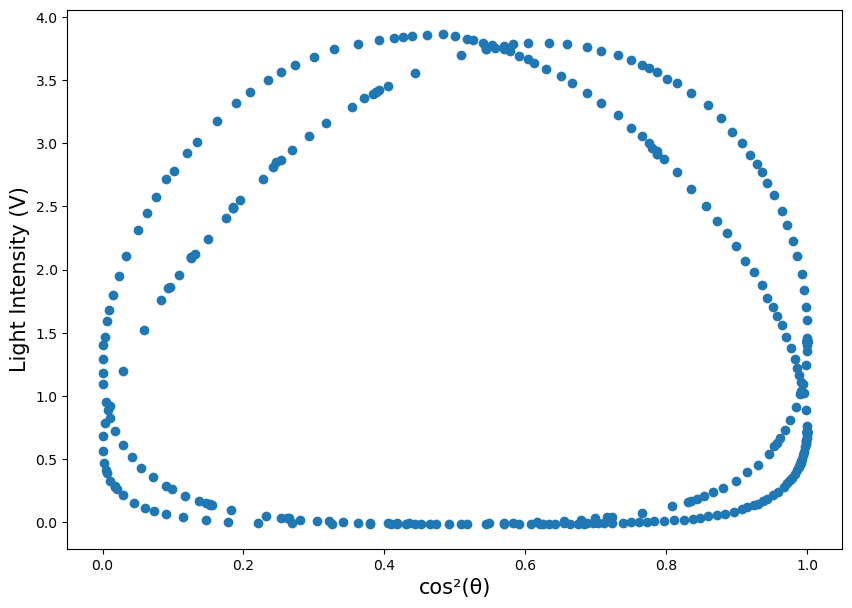

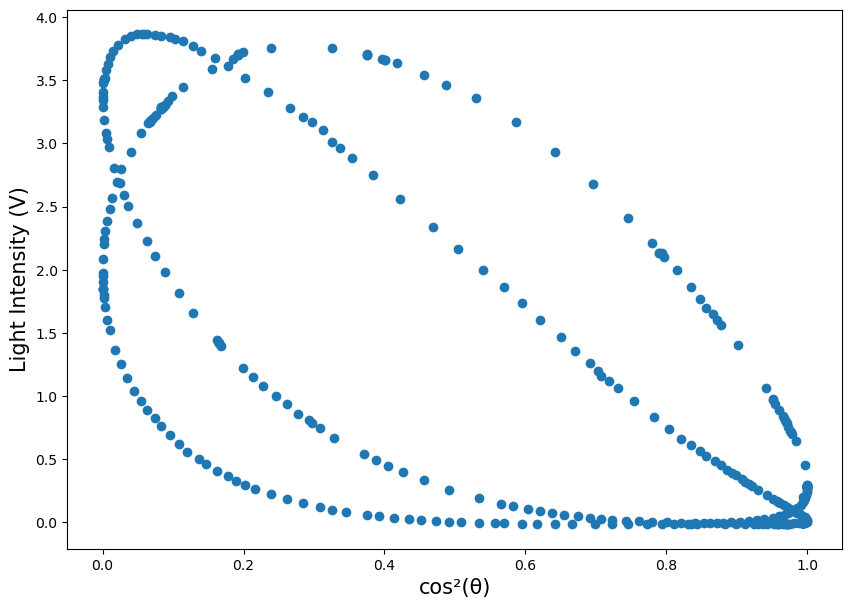

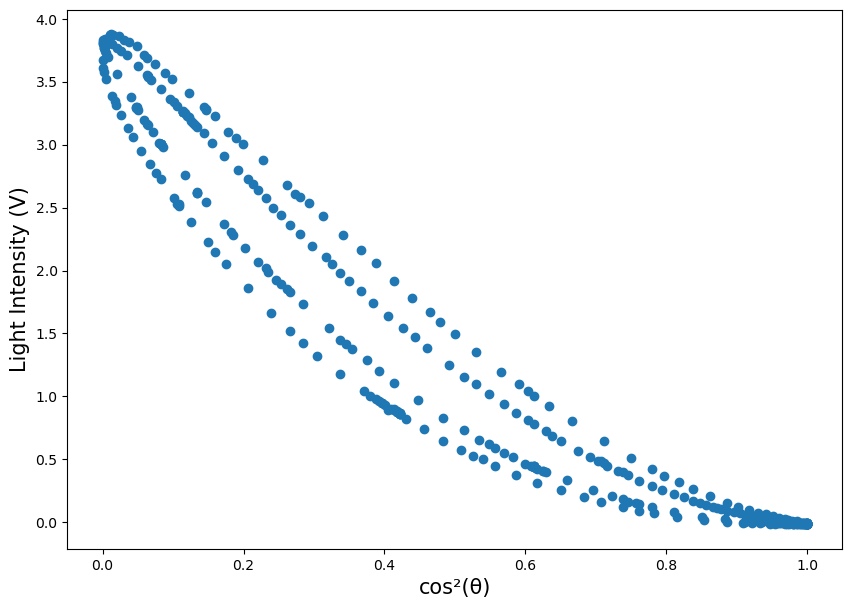

In [167]:
# Intensity vs [cos(θ)]^2
for i in range(0, len(ex2)):
    # make the data
    x = np.array((np.cos(ex2[i]['Sensor Position (Radians)'].to_list()))**2) # (cos(θ))**2
    y = np.array(ex2[i]['Light Intensity (Volts)'].to_list()) # intensity
    # MAKE ERRORBARS
    
    # plot data
    fig, ax = plt.subplots()
    ax.scatter(x, y)
    ax.set_ylabel("Light Intensity (V)", fontsize=15)
    ax.set_xlabel("cos²(θ)", fontsize=15)
    #ax.errorbar(x, y, xerr=x_err, yerr=y_err[i], fmt='none')


    # plot with curve_fit
    # MAYBE MALUS IS FOR INTENSITY VS COS^2?
    #popt, pcov = curve_fit(malus, x, y, p0 = (2))
    #ax.plot(x, malus(x, *popt), label='malus', color='orange')
    #print(popt)

    # save
    fig.set_size_inches(10, 7)
    name = "3p_intensityvscos2_" + str(i) + ".png"
    fig.savefig(name, bbox_inches='tight', pad_inches=0.5)